# Regression Analysis

This notebook examines the relationship between healthcare accessibility, health outcomes, socioeconomic factors, and life expectancy in Germany and India between 1990 and 2024.

The analysis begins with a simple baseline model using Year as the only predictor. More complex healthcare models will be developed progressively.

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [185]:
df = pd.read_csv(r"C:/Users/Admin/OneDrive/Documents/Thesis/master_dataset_updated(in).csv")

df.head()

,Year,Country,Infant_Mortality,GDP_per_Capita,Urban_Population,Total_Population,Obesity_Prevalence,Cardiovascular_Deaths_Rate,Chronic_Respiratory_Deaths_Rate,Diabetes_Deaths_Rate,...,UHC_Coverage_Index,NCD_Mortality_Probability,Diabetes_Prevalence,Hospital_Density,Life_Expectancy,Physician_Density,Hospital_Beds_Per_1000,Birth_Rate,Health_Expenditure_y,Out_of_Pocket
0,1990,Germany,7.0,19467.81503,63557004,79433029,15.49,544.715720,48.364862,26.707671,...,84.0,13.25,5.18,2.235365,75.085634,2.745,10.4,11.4,8.404808,14.119194
1,1991,Germany,6.6,21000.69555,64026873,80013896,15.91,528.670040,47.457809,27.173112,...,84.0,13.25,5.37,2.235365,75.319512,2.745,10.1,10.4,8.516111,14.041934
2,1992,Germany,6.2,21745.81780,64520686,80624598,16.35,505.608833,45.389481,27.534647,...,84.0,13.25,5.55,2.235365,75.819512,2.816,9.9,10.0,8.627414,13.964675
3,1993,Germany,5.8,21900.19791,64951514,81156363,16.80,506.565680,45.945774,30.114751,...,84.0,13.25,5.72,2.235365,75.870732,2.904,9.7,9.8,8.738717,13.887415
4,1994,Germany,5.5,22869.21244,65182721,81438348,17.30,493.041589,44.860060,29.862112,...,84.0,13.25,5.88,2.235365,76.270732,2.977,9.7,9.5,8.850019,13.810155


In [187]:
df.shape

(70, 21)

In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             70 non-null     int64  
 1   Country                          70 non-null     object 
 2   Infant_Mortality                 70 non-null     float64
 3   GDP_per_Capita                   70 non-null     float64
 4   Urban_Population                 70 non-null     int64  
 5   Total_Population                 70 non-null     int64  
 6   Obesity_Prevalence               70 non-null     float64
 7   Cardiovascular_Deaths_Rate       70 non-null     float64
 8   Chronic_Respiratory_Deaths_Rate  70 non-null     float64
 9   Diabetes_Deaths_Rate             70 non-null     float64
 10  Neoplasms_Deaths_Rate            70 non-null     float64
 11  UHC_Coverage_Index               70 non-null     float64
 12  NCD_Mortality_Probabilit

In [191]:
df.isnull().sum()

Year                               0
Country                            0
Infant_Mortality                   0
GDP_per_Capita                     0
Urban_Population                   0
Total_Population                   0
Obesity_Prevalence                 0
Cardiovascular_Deaths_Rate         0
Chronic_Respiratory_Deaths_Rate    0
Diabetes_Deaths_Rate               0
Neoplasms_Deaths_Rate              0
UHC_Coverage_Index                 0
NCD_Mortality_Probability          0
Diabetes_Prevalence                0
Hospital_Density                   0
Life_Expectancy                    0
Physician_Density                  0
Hospital_Beds_Per_1000             0
Birth_Rate                         0
Health_Expenditure_y               0
Out_of_Pocket                      0
dtype: int64

In [193]:
print(df["Country"].unique())
print(df["Year"].min())
print(df["Year"].max())

['Germany' 'India']
1990
2024


In [195]:
df = df.sort_values(["Country", "Year"]).reset_index(drop=True)

df.head()

,Year,Country,Infant_Mortality,GDP_per_Capita,Urban_Population,Total_Population,Obesity_Prevalence,Cardiovascular_Deaths_Rate,Chronic_Respiratory_Deaths_Rate,Diabetes_Deaths_Rate,...,UHC_Coverage_Index,NCD_Mortality_Probability,Diabetes_Prevalence,Hospital_Density,Life_Expectancy,Physician_Density,Hospital_Beds_Per_1000,Birth_Rate,Health_Expenditure_y,Out_of_Pocket
0,1990,Germany,7.0,19467.81503,63557004,79433029,15.49,544.715720,48.364862,26.707671,...,84.0,13.25,5.18,2.235365,75.085634,2.745,10.4,11.4,8.404808,14.119194
1,1991,Germany,6.6,21000.69555,64026873,80013896,15.91,528.670040,47.457809,27.173112,...,84.0,13.25,5.37,2.235365,75.319512,2.745,10.1,10.4,8.516111,14.041934
2,1992,Germany,6.2,21745.81780,64520686,80624598,16.35,505.608833,45.389481,27.534647,...,84.0,13.25,5.55,2.235365,75.819512,2.816,9.9,10.0,8.627414,13.964675
3,1993,Germany,5.8,21900.19791,64951514,81156363,16.80,506.565680,45.945774,30.114751,...,84.0,13.25,5.72,2.235365,75.870732,2.904,9.7,9.8,8.738717,13.887415
4,1994,Germany,5.5,22869.21244,65182721,81438348,17.30,493.041589,44.860060,29.862112,...,84.0,13.25,5.88,2.235365,76.270732,2.977,9.7,9.5,8.850019,13.810155


In [197]:
df["Life_Expectancy"].describe()

count    70.000000
mean     72.279807
std       7.467225
min      58.618000
25%      65.914000
50%      73.660317
75%      79.433537
max      81.292683
Name: Life_Expectancy, dtype: float64

In [199]:
df["Life_Expectancy"].isnull().sum()

0

In [201]:
model0_data = df[["Year", "Life_Expectancy"]].dropna()

model0_data.head()

,Year,Life_Expectancy
0,1990,75.085634
1,1991,75.319512
2,1992,75.819512
3,1993,75.870732
4,1994,76.270732


In [203]:
model0_data.shape

(70, 2)

In [205]:
X = model0_data[["Year"]]
y = model0_data["Life_Expectancy"]

In [207]:
model0 = LinearRegression()

model0.fit(X, y)

LinearRegression()

In [209]:
germany_data = df[df["Country"] == "Germany"][["Year", "Life_Expectancy"]].dropna()

germany_data.head()

,Year,Life_Expectancy
0,1990,75.085634
1,1991,75.319512
2,1992,75.819512
3,1993,75.870732
4,1994,76.270732


In [211]:
germany_data = df[df["Country"] == "Germany"][["Year", "Life_Expectancy"]].dropna()

germany_data.head()

,Year,Life_Expectancy
0,1990,75.085634
1,1991,75.319512
2,1992,75.819512
3,1993,75.870732
4,1994,76.270732


In [213]:
X_germany = germany_data[["Year"]]
y_germany = germany_data["Life_Expectancy"]

In [215]:
model_germany = LinearRegression()

model_germany.fit(X_germany, y_germany)

LinearRegression()

In [217]:
print("Germany coefficient:", model_germany.coef_[0])
print("Germany intercept:", model_germany.intercept_)

Germany coefficient: 0.18249820992156862
Germany intercept: -287.3001505177311


In [219]:
y_pred_germany = model_germany.predict(X_germany)

y_pred_germany[:5]

array([75.87128723, 76.05378544, 76.23628365, 76.41878186, 76.60128007])

In [221]:
r2_germany = r2_score(y_germany, y_pred_germany)

print("Germany R²:", r2_germany)

Germany R²: 0.9220516821098859


In [223]:
rmse_germany = np.sqrt(
    mean_squared_error(y_germany, y_pred_germany)
)

print("Germany RMSE:", rmse_germany)

Germany RMSE: 0.5359008382890955


In [225]:
germany_baseline = pd.DataFrame({
    "Country": ["Germany"],
    "Model": ["Baseline: Life Expectancy ~ Year"],
    "Coefficient_Year": [model_germany.coef_[0]],
    "Intercept": [model_germany.intercept_],
    "R2": [r2_germany],
    "RMSE": [rmse_germany]
})

germany_baseline

,Country,Model,Coefficient_Year,Intercept,R2,RMSE
0,Germany,Baseline: Life Expectancy ~ Year,0.182498,-287.300151,0.922052,0.535901


In [227]:
india_data = df[df["Country"] == "India"][["Year", "Life_Expectancy"]].dropna()

india_data.head()

,Year,Life_Expectancy
35,1990,58.618
36,1991,59.032
37,1992,59.445
38,1993,59.823
39,1994,60.237


In [229]:
india_data.shape

(35, 2)

In [231]:
X_india = india_data[["Year"]]
y_india = india_data["Life_Expectancy"]

In [233]:
model_india = LinearRegression()

model_india.fit(X_india, y_india)

LinearRegression()

In [235]:
print("India coefficient:", model_india.coef_[0])
print("India intercept:", model_india.intercept_)

India coefficient: 0.39726386554621845
India intercept: -731.7227210084034


In [237]:
y_pred_india = model_india.predict(X_india)

y_pred_india[:5]

array([58.83237143, 59.22963529, 59.62689916, 60.02416303, 60.42142689])

In [239]:
r2_india = r2_score(y_india, y_pred_india)

print("India R²:", r2_india)

India R²: 0.9683581482163832


In [241]:
rmse_india = np.sqrt(
    mean_squared_error(y_india, y_pred_india)
)

print("India RMSE:", rmse_india)

India RMSE: 0.7252572691194185


In [243]:
india_baseline = pd.DataFrame({
    "Country": ["India"],
    "Model": ["Baseline: Life Expectancy ~ Year"],
    "Coefficient_Year": [model_india.coef_[0]],
    "Intercept": [model_india.intercept_],
    "R2": [r2_india],
    "RMSE": [rmse_india]
})

india_baseline

,Country,Model,Coefficient_Year,Intercept,R2,RMSE
0,India,Baseline: Life Expectancy ~ Year,0.397264,-731.722721,0.968358,0.725257


In [245]:
baseline_results = pd.concat(
    [germany_baseline, india_baseline],
    ignore_index=True
)

baseline_results

,Country,Model,Coefficient_Year,Intercept,R2,RMSE
0,Germany,Baseline: Life Expectancy ~ Year,0.182498,-287.300151,0.922052,0.535901
1,India,Baseline: Life Expectancy ~ Year,0.397264,-731.722721,0.968358,0.725257


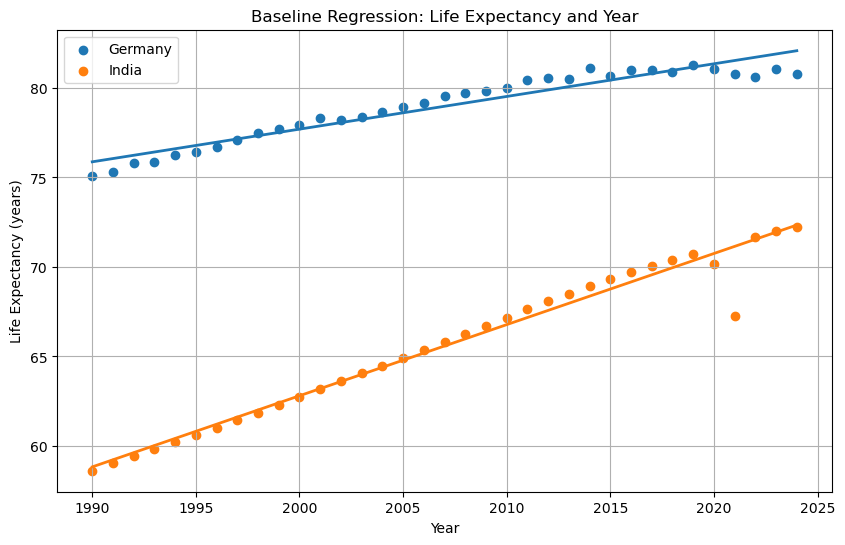

In [247]:
plt.figure(figsize=(10, 6))

# Germany
plt.scatter(
    X_germany,
    y_germany,
    label="Germany"
)

plt.plot(
    X_germany,
    y_pred_germany,
    linewidth=2
)

# India
plt.scatter(
    X_india,
    y_india,
    label="India"
)

plt.plot(
    X_india,
    y_pred_india,
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.title("Baseline Regression: Life Expectancy and Year")
plt.legend()
plt.grid(True)

plt.savefig(
    "figures/baseline_life_expectancy_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [248]:
baseline_results.to_csv(
    "baseline_regression_results.csv",
    index=False
)

In [249]:
baseline_results

,Country,Model,Coefficient_Year,Intercept,R2,RMSE
0,Germany,Baseline: Life Expectancy ~ Year,0.182498,-287.300151,0.922052,0.535901
1,India,Baseline: Life Expectancy ~ Year,0.397264,-731.722721,0.968358,0.725257


# Model 1: Healthcare Accessibility

This model examines the association between healthcare accessibility indicators and life expectancy separately for Germany and India.

The dependent variable is Life Expectancy. The explanatory variables are Physician Density, Hospital Beds per 1,000 Population, Health Expenditure, and Out-of-Pocket Expenditure.

Separate models are estimated for Germany and India to account for differences in their healthcare systems and development trajectories.

Because the analysis uses observational data, coefficients are interpreted as associations rather than causal effects.

In [254]:
germany_model1 = df[
    df["Country"] == "Germany"
][[
    "Year",
    "Life_Expectancy",
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Health_Expenditure_y",
    "Out_of_Pocket"
]].copy()

germany_model1.head()

,Year,Life_Expectancy,Physician_Density,Hospital_Beds_Per_1000,Health_Expenditure_y,Out_of_Pocket
0,1990,75.085634,2.745,10.4,8.404808,14.119194
1,1991,75.319512,2.745,10.1,8.516111,14.041934
2,1992,75.819512,2.816,9.9,8.627414,13.964675
3,1993,75.870732,2.904,9.7,8.738717,13.887415
4,1994,76.270732,2.977,9.7,8.850019,13.810155


In [256]:
germany_model1.isnull().sum()

Year                      0
Life_Expectancy           0
Physician_Density         0
Hospital_Beds_Per_1000    0
Health_Expenditure_y      0
Out_of_Pocket             0
dtype: int64

In [258]:
germany_model1.shape

(35, 6)

In [260]:
X_germany_1 = germany_model1[
    [
        "Physician_Density",
        "Hospital_Beds_Per_1000",
        "Health_Expenditure_y",
        "Out_of_Pocket"
    ]
]

y_germany_1 = germany_model1["Life_Expectancy"]

In [262]:
model1_germany = LinearRegression()

model1_germany.fit(
    X_germany_1,
    y_germany_1
)

LinearRegression()

In [264]:
y_pred_germany_1 = model1_germany.predict(X_germany_1)

In [266]:
r2_germany_1 = r2_score(
    y_germany_1,
    y_pred_germany_1
)

print("Germany Model 1 R²:", r2_germany_1)

Germany Model 1 R²: 0.9647745454594101


In [268]:
n_germany = len(y_germany_1)
p_germany = X_germany_1.shape[1]

adjusted_r2_germany_1 = (
    1 - (1 - r2_germany_1)
    * (n_germany - 1)
    / (n_germany - p_germany - 1)
)

print("Germany Adjusted R²:", adjusted_r2_germany_1)

Germany Adjusted R²: 0.9600778181873314


In [270]:
from sklearn.metrics import mean_absolute_error

mae_germany_1 = mean_absolute_error(
    y_germany_1,
    y_pred_germany_1
)

print("Germany MAE:", mae_germany_1)

Germany MAE: 0.2973156422439794


In [272]:
rmse_germany_1 = np.sqrt(
    mean_squared_error(
        y_germany_1,
        y_pred_germany_1
    )
)

print("Germany RMSE:", rmse_germany_1)

Germany RMSE: 0.3602544594656243


In [274]:
coefficients_germany = pd.DataFrame({
    "Predictor": X_germany_1.columns,
    "Coefficient": model1_germany.coef_
})

coefficients_germany

,Predictor,Coefficient
0,Physician_Density,1.609173
1,Hospital_Beds_Per_1000,-2.076954
2,Health_Expenditure_y,-0.468599
3,Out_of_Pocket,0.148249


In [276]:
print("Germany Intercept:", model1_germany.intercept_)

Germany Intercept: 94.0144042435228


In [278]:
import statsmodels.api as sm

In [280]:
X_germany_sm = sm.add_constant(X_germany_1)

ols_germany_1 = sm.OLS(
    y_germany_1,
    X_germany_sm
).fit()

print(ols_germany_1.summary())

                            OLS Regression Results                            
Dep. Variable:        Life_Expectancy   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                     205.4
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           2.47e-21
Time:                        16:29:05   Log-Likelihood:                -13.930
No. Observations:                  35   AIC:                             37.86
Df Residuals:                      30   BIC:                             45.64
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     94

In [282]:
germany_coefficients = pd.DataFrame({
    "Coefficient": ols_germany_1.params,
    "P_Value": ols_germany_1.pvalues,
    "CI_Lower": ols_germany_1.conf_int()[0],
    "CI_Upper": ols_germany_1.conf_int()[1]
})

germany_coefficients

,Coefficient,P_Value,CI_Lower,CI_Upper
const,94.014404,2.265249e-16,82.155168,105.873641
Physician_Density,1.609173,4.994316e-03,0.524651,2.693694
Hospital_Beds_Per_1000,-2.076954,2.049665e-07,-2.710760,-1.443149
Health_Expenditure_y,-0.468599,7.126420e-02,-0.980355,0.043157
Out_of_Pocket,0.148249,2.321500e-01,-0.100018,0.396516


In [284]:
germany_coefficients.to_csv(
    "germany_model1_coefficients.csv"
)

In [286]:
germany_model1_summary = pd.DataFrame({
    "Country": ["Germany"],
    "Model": ["Model 1 - Healthcare Accessibility"],
    "R2": [ols_germany_1.rsquared],
    "Adjusted_R2": [ols_germany_1.rsquared_adj],
    "MAE": [mae_germany_1],
    "RMSE": [rmse_germany_1]
})

germany_model1_summary

,Country,Model,R2,Adjusted_R2,MAE,RMSE
0,Germany,Model 1 - Healthcare Accessibility,0.964775,0.960078,0.297316,0.360254


In [288]:
germany_model1_summary.to_csv(
    "germany_model1_summary.csv",
    index=False
)

In [290]:
india_model1 = df[
    df["Country"] == "India"
][[
    "Year",
    "Life_Expectancy",
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Health_Expenditure_y",
    "Out_of_Pocket"
]].copy()

india_model1.head()

,Year,Life_Expectancy,Physician_Density,Hospital_Beds_Per_1000,Health_Expenditure_y,Out_of_Pocket
35,1990,58.618,1.231000,0.769800,4.544816,91.589157
36,1991,59.032,1.231000,0.787000,4.499428,90.265202
37,1992,59.445,1.208565,0.936222,4.454041,88.941247
38,1993,59.823,1.186130,1.085444,4.408654,87.617293
39,1994,60.237,1.163696,1.234667,4.363266,86.293338


In [292]:
india_model1.isnull().sum()

Year                      0
Life_Expectancy           0
Physician_Density         0
Hospital_Beds_Per_1000    0
Health_Expenditure_y      0
Out_of_Pocket             0
dtype: int64

In [294]:
india_model1.shape

(35, 6)

In [296]:
X_india_1 = india_model1[
    [
        "Physician_Density",
        "Hospital_Beds_Per_1000",
        "Health_Expenditure_y",
        "Out_of_Pocket"
    ]
]

y_india_1 = india_model1["Life_Expectancy"]

In [298]:
model1_india = LinearRegression()

model1_india.fit(
    X_india_1,
    y_india_1
)

LinearRegression()

In [300]:
y_pred_india_1 = model1_india.predict(X_india_1)

In [302]:
r2_india_1 = r2_score(
    y_india_1,
    y_pred_india_1
)

print("India Model 1 R²:", r2_india_1)

India Model 1 R²: 0.9566286169878566


In [304]:
n_india = len(y_india_1)
p_india = X_india_1.shape[1]

adjusted_r2_india_1 = (
    1 - (1 - r2_india_1)
    * (n_india - 1)
    / (n_india - p_india - 1)
)

print("India Model 1 Adjusted R²:", adjusted_r2_india_1)

India Model 1 Adjusted R²: 0.9508457659195708


In [306]:
mae_india_1 = mean_absolute_error(
    y_india_1,
    y_pred_india_1
)

print("India Model 1 MAE:", mae_india_1)

India Model 1 MAE: 0.5342395473491028


In [308]:
rmse_india_1 = np.sqrt(
    mean_squared_error(
        y_india_1,
        y_pred_india_1
    )
)

print("India Model 1 RMSE:", rmse_india_1)

India Model 1 RMSE: 0.8491077013268981


In [310]:
X_india_sm = sm.add_constant(X_india_1)

ols_india_1 = sm.OLS(
    y_india_1,
    X_india_sm
).fit()

print(ols_india_1.summary())

                            OLS Regression Results                            
Dep. Variable:        Life_Expectancy   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     165.4
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           5.55e-20
Time:                        16:29:20   Log-Likelihood:                -43.938
No. Observations:                  35   AIC:                             97.88
Df Residuals:                      30   BIC:                             105.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     90

In [312]:
india_coefficients = pd.DataFrame({
    "Coefficient": ols_india_1.params,
    "P_Value": ols_india_1.pvalues,
    "CI_Lower": ols_india_1.conf_int()[0],
    "CI_Upper": ols_india_1.conf_int()[1]
})

india_coefficients

,Coefficient,P_Value,CI_Lower,CI_Upper
const,90.781016,7.844049e-31,87.180141,94.381890
Physician_Density,-11.212031,2.674872e-05,-15.836908,-6.587154
Hospital_Beds_Per_1000,-0.473051,3.882955e-01,-1.576622,0.630520
Health_Expenditure_y,-2.051838,1.036116e-02,-3.583781,-0.519895
Out_of_Pocket,-0.092134,3.686721e-03,-0.151876,-0.032392


In [314]:
india_coefficients.to_csv(
    "india_model1_coefficients.csv"
)

In [316]:
india_model1_summary = pd.DataFrame({
    "Country": ["India"],
    "Model": ["Model 1 - Healthcare Accessibility"],
    "R2": [ols_india_1.rsquared],
    "Adjusted_R2": [ols_india_1.rsquared_adj],
    "MAE": [mae_india_1],
    "RMSE": [rmse_india_1]
})

india_model1_summary

,Country,Model,R2,Adjusted_R2,MAE,RMSE
0,India,Model 1 - Healthcare Accessibility,0.956629,0.950846,0.53424,0.849108


In [318]:
india_model1_summary.to_csv(
    "india_model1_summary.csv",
    index=False
)

## Model 1 Diagnostic Analysis: Multicollinearity

Before interpreting individual regression coefficients, multicollinearity among the healthcare accessibility predictors is assessed using correlation matrices and Variance Inflation Factors (VIF).

In [321]:
germany_corr = X_germany_1.corr()

germany_corr

,Physician_Density,Hospital_Beds_Per_1000,Health_Expenditure_y,Out_of_Pocket
Physician_Density,1.000000,-0.953820,0.964540,-0.780782
Hospital_Beds_Per_1000,-0.953820,1.000000,-0.936366,0.697070
Health_Expenditure_y,0.964540,-0.936366,1.000000,-0.820788
Out_of_Pocket,-0.780782,0.697070,-0.820788,1.000000


In [323]:
india_corr = X_india_1.corr()

india_corr

,Physician_Density,Hospital_Beds_Per_1000,Health_Expenditure_y,Out_of_Pocket
Physician_Density,1.000000,-0.474890,0.861646,0.884450
Hospital_Beds_Per_1000,-0.474890,1.000000,-0.298889,-0.342066
Health_Expenditure_y,0.861646,-0.298889,1.000000,0.894536
Out_of_Pocket,0.884450,-0.342066,0.894536,1.000000


In [325]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_germany_vif = sm.add_constant(X_germany_1)

vif_germany = pd.DataFrame()

vif_germany["Variable"] = X_germany_vif.columns

vif_germany["VIF"] = [
    variance_inflation_factor(
        X_germany_vif.values,
        i
    )
    for i in range(X_germany_vif.shape[1])
]

vif_germany

,Variable,VIF
0,const,7794.506207
1,Physician_Density,20.992373
2,Hospital_Beds_Per_1000,13.525365
3,Health_Expenditure_y,19.709281
4,Out_of_Pocket,3.599282


In [327]:
X_india_vif = sm.add_constant(X_india_1)

vif_india = pd.DataFrame()

vif_india["Variable"] = X_india_vif.columns

vif_india["VIF"] = [
    variance_inflation_factor(
        X_india_vif.values,
        i
    )
    for i in range(X_india_vif.shape[1])
]

vif_india

,Variable,VIF
0,const,129.355323
1,Physician_Density,6.318903
2,Hospital_Beds_Per_1000,1.380769
3,Health_Expenditure_y,5.824072
4,Out_of_Pocket,6.710766


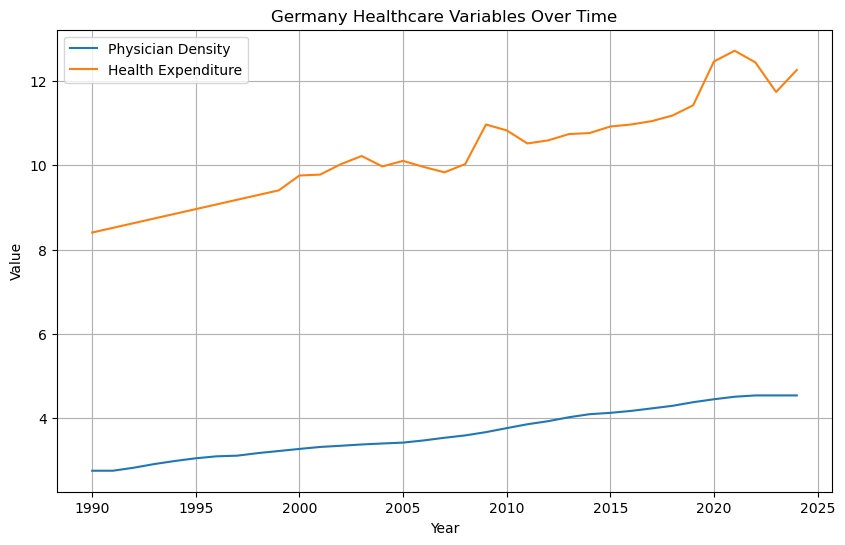

In [329]:
plt.figure(figsize=(10, 6))

plt.plot(
    germany_model1["Year"],
    germany_model1["Physician_Density"],
    label="Physician Density"
)

plt.plot(
    germany_model1["Year"],
    germany_model1["Health_Expenditure_y"],
    label="Health Expenditure"
)

plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Germany Healthcare Variables Over Time")
plt.legend()
plt.grid(True)

plt.show()

In [330]:
vif_germany

,Variable,VIF
0,const,7794.506207
1,Physician_Density,20.992373
2,Hospital_Beds_Per_1000,13.525365
3,Health_Expenditure_y,19.709281
4,Out_of_Pocket,3.599282


In [333]:
vif_india

,Variable,VIF
0,const,129.355323
1,Physician_Density,6.318903
2,Hospital_Beds_Per_1000,1.380769
3,Health_Expenditure_y,5.824072
4,Out_of_Pocket,6.710766


# Model 1B: Time-Adjusted Healthcare Accessibility

Model 1B extends the healthcare accessibility model by including Year as a predictor.

This allows us to examine whether healthcare accessibility indicators are associated with life expectancy beyond the underlying long-term temporal trend.

Because the data are observational and the predictors may be correlated with time, coefficients are interpreted as associations rather than causal effects.

In [338]:
X_germany_1b = germany_model1[
    [
        "Year",
        "Physician_Density",
        "Hospital_Beds_Per_1000",
        "Health_Expenditure_y",
        "Out_of_Pocket"
    ]
]

y_germany_1b = germany_model1["Life_Expectancy"]

X_germany_1b_sm = sm.add_constant(X_germany_1b)

ols_germany_1b = sm.OLS(
    y_germany_1b,
    X_germany_1b_sm
).fit()

print(ols_germany_1b.summary())

                            OLS Regression Results                            
Dep. Variable:        Life_Expectancy   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     167.5
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           1.81e-20
Time:                        16:30:10   Log-Likelihood:                -13.031
No. Observations:                  35   AIC:                             38.06
Df Residuals:                      29   BIC:                             47.39
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    436

In [340]:
X_india_1b = india_model1[
    [
        "Year",
        "Physician_Density",
        "Hospital_Beds_Per_1000",
        "Health_Expenditure_y",
        "Out_of_Pocket"
    ]
]

y_india_1b = india_model1["Life_Expectancy"]

X_india_1b_sm = sm.add_constant(X_india_1b)

ols_india_1b = sm.OLS(
    y_india_1b,
    X_india_1b_sm
).fit()

print(ols_india_1b.summary())

                            OLS Regression Results                            
Dep. Variable:        Life_Expectancy   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     276.8
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           1.54e-23
Time:                        16:30:27   Log-Likelihood:                -30.842
No. Observations:                  35   AIC:                             73.68
Df Residuals:                      29   BIC:                             83.02
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                  -1018

In [342]:
X_germany_1b_vif = sm.add_constant(X_germany_1b)

vif_germany_1b = pd.DataFrame({
    "Variable": X_germany_1b_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_germany_1b_vif.values,
            i
        )
        for i in range(X_germany_1b_vif.shape[1])
    ]
})

vif_germany_1b

,Variable,VIF
0,const,1.802522e+07
1,Year,4.620876e+02
2,Physician_Density,2.449365e+02
3,Hospital_Beds_Per_1000,5.678354e+01
4,Health_Expenditure_y,1.977716e+01
5,Out_of_Pocket,3.619539e+00


In [344]:
X_india_1b_vif = sm.add_constant(X_india_1b)

vif_india_1b = pd.DataFrame({
    "Variable": X_india_1b_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_india_1b_vif.values,
            i
        )
        for i in range(X_india_1b_vif.shape[1])
    ]
})

vif_india_1b

,Variable,VIF
0,const,3.242471e+06
1,Year,7.734477e+01
2,Physician_Density,1.946417e+01
3,Hospital_Beds_Per_1000,1.776286e+00
4,Health_Expenditure_y,6.468789e+00
5,Out_of_Pocket,3.029111e+01


In [346]:
features = [
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Health_Expenditure_y",
    "Out_of_Pocket"
]

train_germany = germany_model1[
    germany_model1["Year"] <= 2016
].copy()

test_germany = germany_model1[
    germany_model1["Year"] > 2016
].copy()

X_train = train_germany[features]
y_train = train_germany["Life_Expectancy"]

X_test = test_germany[features]
y_test = test_germany["Life_Expectancy"]

In [348]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

model_germany = LinearRegression()

model_germany.fit(X_train, y_train)

y_pred = model_germany.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("Germany Test R²:", test_r2)
print("Germany Test MAE:", test_mae)
print("Germany Test RMSE:", test_rmse)

Germany Test R²: -52.438904923423365
Germany Test MAE: 1.2944232000477243
Germany Test RMSE: 1.4243887814998504


In [350]:
train_india = india_model1[
    india_model1["Year"] <= 2016
].copy()

test_india = india_model1[
    india_model1["Year"] > 2016
].copy()

X_train = train_india[features]
y_train = train_india["Life_Expectancy"]

X_test = test_india[features]
y_test = test_india["Life_Expectancy"]

model_india = LinearRegression()

model_india.fit(X_train, y_train)

y_pred = model_india.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("India Test R²:", test_r2)
print("India Test MAE:", test_mae)
print("India Test RMSE:", test_rmse)

India Test R²: -2.0557209496210147
India Test MAE: 2.2817488064955924
India Test RMSE: 2.5770736209394753


# Model 1 — Out-of-Sample Evaluation and Diagnostics

Model 1 predicts Life Expectancy using healthcare accessibility and healthcare financing indicators.

The purpose of this section is to evaluate whether the model can generalize to previously unseen observations rather than only explaining the historical data used during model fitting.

A chronological train-test split is used because the dataset represents a time series. Random splitting is avoided because it could allow information from later years to influence model training.

In [355]:
features = [
    "Physician_Density",
    "Hospital_Beds_Per_1000",
    "Health_Expenditure_y",
    "Out_of_Pocket"
]

target = "Life_Expectancy"

In [357]:
train_germany = germany_model1[
    germany_model1["Year"] <= 2016
].copy()

test_germany = germany_model1[
    germany_model1["Year"] > 2016
].copy()

print("Germany training years:",
      train_germany["Year"].min(),
      "to",
      train_germany["Year"].max())

print("Germany testing years:",
      test_germany["Year"].min(),
      "to",
      test_germany["Year"].max())

Germany training years: 1990 to 2016
Germany testing years: 2017 to 2024


In [359]:
X_train_germany = train_germany[features]
y_train_germany = train_germany[target]

X_test_germany = test_germany[features]
y_test_germany = test_germany[target]

In [361]:
from sklearn.linear_model import LinearRegression

model1_germany = LinearRegression()

model1_germany.fit(
    X_train_germany,
    y_train_germany
)

LinearRegression()

In [363]:
y_pred_germany = model1_germany.predict(
    X_test_germany
)

In [365]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

r2_germany = r2_score(
    y_test_germany,
    y_pred_germany
)

mae_germany = mean_absolute_error(
    y_test_germany,
    y_pred_germany
)

rmse_germany = mean_squared_error(
    y_test_germany,
    y_pred_germany
) ** 0.5

print("Germany Model 1")
print("----------------")
print("Test R²:", round(r2_germany, 4))
print("Test MAE:", round(mae_germany, 4))
print("Test RMSE:", round(rmse_germany, 4))

Germany Model 1
----------------
Test R²: -52.4389
Test MAE: 1.2944
Test RMSE: 1.4244


In [367]:
train_india = india_model1[
    india_model1["Year"] <= 2016
].copy()

test_india = india_model1[
    india_model1["Year"] > 2016
].copy()

print("India training years:",
      train_india["Year"].min(),
      "to",
      train_india["Year"].max())

print("India testing years:",
      test_india["Year"].min(),
      "to",
      test_india["Year"].max())

India training years: 1990 to 2016
India testing years: 2017 to 2024


In [369]:
X_train_india = train_india[features]
y_train_india = train_india[target]

X_test_india = test_india[features]
y_test_india = test_india[target]

In [371]:
model1_india = LinearRegression()

model1_india.fit(
    X_train_india,
    y_train_india
)

LinearRegression()

In [373]:
y_pred_india = model1_india.predict(
    X_test_india
)

In [375]:
r2_india = r2_score(
    y_test_india,
    y_pred_india
)

mae_india = mean_absolute_error(
    y_test_india,
    y_pred_india
)

rmse_india = mean_squared_error(
    y_test_india,
    y_pred_india
) ** 0.5

print("India Model 1")
print("----------------")
print("Test R²:", round(r2_india, 4))
print("Test MAE:", round(mae_india, 4))
print("Test RMSE:", round(rmse_india, 4))

India Model 1
----------------
Test R²: -2.0557
Test MAE: 2.2817
Test RMSE: 2.5771


# Forecasting Analysis

## Model 0 — Naive Forecast Baseline

The naive forecasting model is used as a baseline for evaluating more advanced forecasting methods.

For each prediction period, the forecast is based on the most recently observed life expectancy value.

The purpose of this model is not to provide the final forecast, but to establish a simple benchmark against which more complex forecasting methods can be compared.

In [378]:
print(germany_model1.columns.tolist())

['Year', 'Life_Expectancy', 'Physician_Density', 'Hospital_Beds_Per_1000', 'Health_Expenditure_y', 'Out_of_Pocket']


In [380]:
print(india_model1.columns.tolist())

['Year', 'Life_Expectancy', 'Physician_Density', 'Hospital_Beds_Per_1000', 'Health_Expenditure_y', 'Out_of_Pocket']


In [382]:
germany_model1[["Year", "Life_Expectancy"]].head()

,Year,Life_Expectancy
0,1990,75.085634
1,1991,75.319512
2,1992,75.819512
3,1993,75.870732
4,1994,76.270732


In [384]:
india_model1[["Year", "Life_Expectancy"]].head()

,Year,Life_Expectancy
35,1990,58.618
36,1991,59.032
37,1992,59.445
38,1993,59.823
39,1994,60.237


In [386]:
print("Germany")
print("First year:", germany_model1["Year"].min())
print("Last year:", germany_model1["Year"].max())
print("Number of observations:", germany_model1["Year"].nunique())

Germany
First year: 1990
Last year: 2024
Number of observations: 35


In [388]:
print("India")
print("First year:", india_model1["Year"].min())
print("Last year:", india_model1["Year"].max())
print("Number of observations:", india_model1["Year"].nunique())

India
First year: 1990
Last year: 2024
Number of observations: 35


In [390]:
print("Germany missing values:")
print(germany_model1[["Year", "Life_Expectancy"]].isnull().sum())

print("\nIndia missing values:")
print(india_model1[["Year", "Life_Expectancy"]].isnull().sum())

Germany missing values:
Year               0
Life_Expectancy    0
dtype: int64

India missing values:
Year               0
Life_Expectancy    0
dtype: int64


In [392]:
germany_forecast = germany_model1[
    ["Year", "Life_Expectancy"]
].copy()

germany_forecast = germany_forecast.sort_values("Year").reset_index(drop=True)

In [394]:
india_forecast = india_model1[
    ["Year", "Life_Expectancy"]
].copy()

india_forecast = india_forecast.sort_values("Year").reset_index(drop=True)

In [396]:
germany_forecast.head()

,Year,Life_Expectancy
0,1990,75.085634
1,1991,75.319512
2,1992,75.819512
3,1993,75.870732
4,1994,76.270732


In [400]:
germany_forecast.tail()

,Year,Life_Expectancy
30,2020,81.041463
31,2021,80.790244
32,2022,80.608049
33,2023,81.041463
34,2024,80.792683


In [404]:
india_forecast.head()

,Year,Life_Expectancy
0,1990,58.618
1,1991,59.032
2,1992,59.445
3,1993,59.823
4,1994,60.237


In [406]:
india_forecast.tail()

,Year,Life_Expectancy
30,2020,70.156
31,2021,67.282
32,2022,71.698
33,2023,72.003
34,2024,72.235


In [408]:
germany_split = int(len(germany_forecast) * 0.8)
india_split = int(len(india_forecast) * 0.8)

print("Germany split:", germany_split)
print("India split:", india_split)

Germany split: 28
India split: 28


In [410]:
germany_train = germany_forecast.iloc[:germany_split].copy()
germany_test = germany_forecast.iloc[germany_split:].copy()

In [412]:
india_train = india_forecast.iloc[:india_split].copy()
india_test = india_forecast.iloc[india_split:].copy()

In [414]:
print(
    "Germany training:",
    germany_train["Year"].min(),
    "to",
    germany_train["Year"].max()
)

print(
    "Germany testing:",
    germany_test["Year"].min(),
    "to",
    germany_test["Year"].max()
)

Germany training: 1990 to 2017
Germany testing: 2018 to 2024


In [416]:
print(
    "India training:",
    india_train["Year"].min(),
    "to",
    india_train["Year"].max()
)

print(
    "India testing:",
    india_test["Year"].min(),
    "to",
    india_test["Year"].max()
)

India training: 1990 to 2017
India testing: 2018 to 2024


In [418]:
germany_last_value = germany_train["Life_Expectancy"].iloc[-1]

germany_test["Naive_Forecast"] = germany_last_value

print("Germany naive forecast:", germany_last_value)

Germany naive forecast: 80.99268293


In [420]:
india_last_value = india_train["Life_Expectancy"].iloc[-1]

india_test["Naive_Forecast"] = india_last_value

print("India naive forecast:", india_last_value)

India naive forecast: 70.068


In [422]:
germany_test

,Year,Life_Expectancy,Naive_Forecast
28,2018,80.892683,80.992683
29,2019,81.292683,80.992683
30,2020,81.041463,80.992683
31,2021,80.790244,80.992683
32,2022,80.608049,80.992683
33,2023,81.041463,80.992683
34,2024,80.792683,80.992683


In [424]:
india_test

,Year,Life_Expectancy,Naive_Forecast
28,2018,70.415,70.068
29,2019,70.746,70.068
30,2020,70.156,70.068
31,2021,67.282,70.068
32,2022,71.698,70.068
33,2023,72.003,70.068
34,2024,72.235,70.068


In [426]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [428]:
germany_naive_mae = mean_absolute_error(
    germany_test["Life_Expectancy"],
    germany_test["Naive_Forecast"]
)

germany_naive_rmse = mean_squared_error(
    germany_test["Life_Expectancy"],
    germany_test["Naive_Forecast"]
) ** 0.5

germany_naive_r2 = r2_score(
    germany_test["Life_Expectancy"],
    germany_test["Naive_Forecast"]
)

print("Germany Naive Forecast")
print("----------------------")
print("MAE:", round(germany_naive_mae, 4))
print("RMSE:", round(germany_naive_rmse, 4))
print("R²:", round(germany_naive_r2, 4))

Germany Naive Forecast
----------------------
MAE: 0.1835
RMSE: 0.2183
R²: -0.1143


In [430]:
india_naive_mae = mean_absolute_error(
    india_test["Life_Expectancy"],
    india_test["Naive_Forecast"]
)

india_naive_rmse = mean_squared_error(
    india_test["Life_Expectancy"],
    india_test["Naive_Forecast"]
) ** 0.5

india_naive_r2 = r2_score(
    india_test["Life_Expectancy"],
    india_test["Naive_Forecast"]
)

print("India Naive Forecast")
print("--------------------")
print("MAE:", round(india_naive_mae, 4))
print("RMSE:", round(india_naive_rmse, 4))
print("R²:", round(india_naive_r2, 4))

India Naive Forecast
--------------------
MAE: 1.3759
RMSE: 1.6668
R²: -0.1377


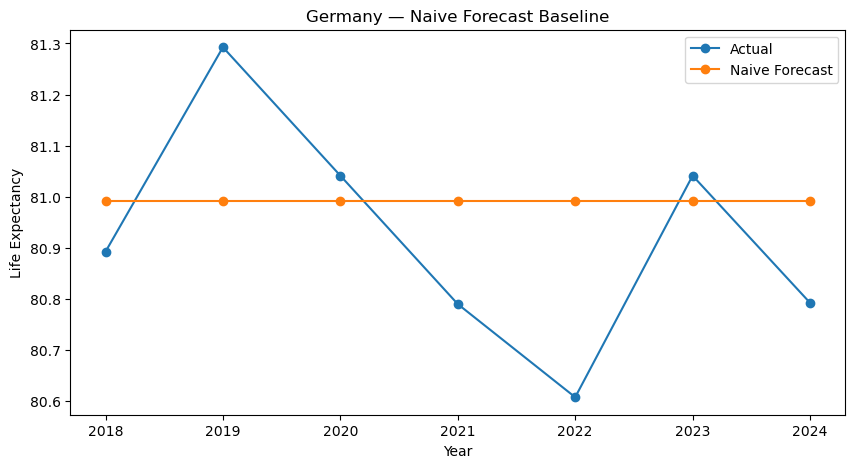

In [432]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    germany_test["Year"],
    germany_test["Life_Expectancy"],
    marker="o",
    label="Actual"
)

plt.plot(
    germany_test["Year"],
    germany_test["Naive_Forecast"],
    marker="o",
    label="Naive Forecast"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.title("Germany — Naive Forecast Baseline")
plt.legend()

plt.show()

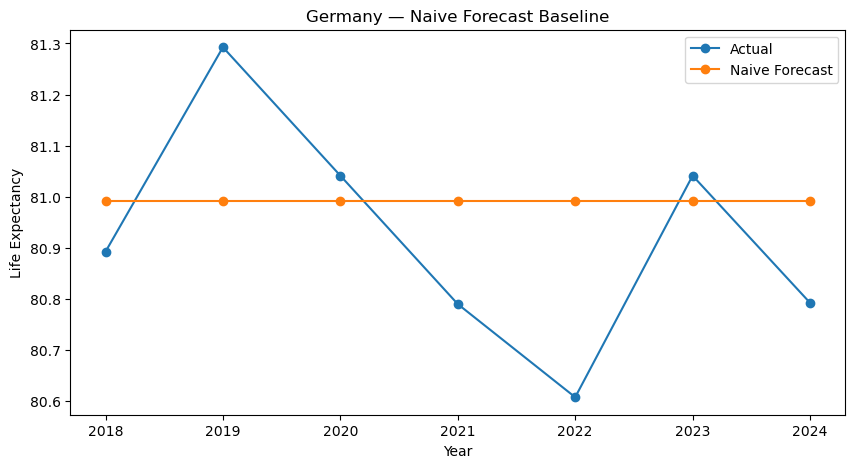

In [434]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    germany_test["Year"],
    germany_test["Life_Expectancy"],
    marker="o",
    label="Actual"
)

plt.plot(
    germany_test["Year"],
    germany_test["Naive_Forecast"],
    marker="o",
    label="Naive Forecast"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.title("Germany — Naive Forecast Baseline")
plt.legend()

plt.show()

In [436]:
forecast_results = pd.DataFrame({
    "Model": ["Naive"],
    "Germany_MAE": [germany_naive_mae],
    "Germany_RMSE": [germany_naive_rmse],
    "India_MAE": [india_naive_mae],
    "India_RMSE": [india_naive_rmse]
})

forecast_results

,Model,Germany_MAE,Germany_RMSE,India_MAE,India_RMSE
0,Naive,0.183519,0.218333,1.375857,1.666761


## Model 1 — Linear Trend Forecast

A linear trend model is used to establish whether the historical trend in life expectancy provides a more informative forecasting signal than the naive persistence baseline.

The model is trained only on the training period and evaluated on the same unseen test period used for the naive baseline.

In [441]:
from sklearn.linear_model import LinearRegression

trend_model_germany = LinearRegression()

X_train_year_germany = germany_train[["Year"]]
y_train_life_germany = germany_train["Life_Expectancy"]

trend_model_germany.fit(
    X_train_year_germany,
    y_train_life_germany
)

LinearRegression()

In [443]:
germany_trend_pred = trend_model_germany.predict(
    germany_test[["Year"]]
)

In [445]:
germany_trend_mae = mean_absolute_error(
    germany_test["Life_Expectancy"],
    germany_trend_pred
)

germany_trend_rmse = mean_squared_error(
    germany_test["Life_Expectancy"],
    germany_trend_pred
) ** 0.5

germany_trend_r2 = r2_score(
    germany_test["Life_Expectancy"],
    germany_trend_pred
)

print("Germany Linear Trend")
print("--------------------")
print("MAE:", round(germany_trend_mae, 4))
print("RMSE:", round(germany_trend_rmse, 4))
print("R²:", round(germany_trend_r2, 4))

Germany Linear Trend
--------------------
MAE: 1.5293
RMSE: 1.6331
R²: -61.3423


In [447]:
trend_model_india = LinearRegression()

X_train_year_india = india_train[["Year"]]
y_train_life_india = india_train["Life_Expectancy"]

trend_model_india.fit(
    X_train_year_india,
    y_train_life_india
)

LinearRegression()

In [449]:
india_trend_pred = trend_model_india.predict(
    india_test[["Year"]]
)

In [451]:
india_trend_mae = mean_absolute_error(
    india_test["Life_Expectancy"],
    india_trend_pred
)

india_trend_rmse = mean_squared_error(
    india_test["Life_Expectancy"],
    india_trend_pred
) ** 0.5

india_trend_r2 = r2_score(
    india_test["Life_Expectancy"],
    india_trend_pred
)

print("India Linear Trend")
print("------------------")
print("MAE:", round(india_trend_mae, 4))
print("RMSE:", round(india_trend_rmse, 4))
print("R²:", round(india_trend_r2, 4))

India Linear Trend
------------------
MAE: 1.2263
RMSE: 1.8755
R²: -0.4405


In [453]:
forecast_results = pd.DataFrame({
    "Model": [
        "Naive",
        "Linear Trend"
    ],
    "Germany_MAE": [
        germany_naive_mae,
        germany_trend_mae
    ],
    "Germany_RMSE": [
        germany_naive_rmse,
        germany_trend_rmse
    ],
    "India_MAE": [
        india_naive_mae,
        india_trend_mae
    ],
    "India_RMSE": [
        india_naive_rmse,
        india_trend_rmse
    ]
})

forecast_results

,Model,Germany_MAE,Germany_RMSE,India_MAE,India_RMSE
0,Naive,0.183519,0.218333,1.375857,1.666761
1,Linear Trend,1.529296,1.633075,1.226341,1.875490


## Model 2 — Holt's Exponential Smoothing

Holt's exponential smoothing method is evaluated to determine whether incorporating both the current level and evolving trend of life expectancy improves forecasting performance compared with the naive and linear trend baselines.

The model is evaluated using the same chronological test period as the previous forecasting models.

In [456]:
from statsmodels.tsa.holtwinters import Holt

In [458]:
holt_germany = Holt(
    germany_train["Life_Expectancy"],
    initialization_method="estimated"
).fit()

In [460]:
germany_holt_pred = holt_germany.forecast(
    len(germany_test)
)

In [462]:
germany_holt_mae = mean_absolute_error(
    germany_test["Life_Expectancy"],
    germany_holt_pred
)

germany_holt_rmse = mean_squared_error(
    germany_test["Life_Expectancy"],
    germany_holt_pred
) ** 0.5

germany_holt_r2 = r2_score(
    germany_test["Life_Expectancy"],
    germany_holt_pred
)

print("Germany Holt")
print("------------")
print("MAE:", round(germany_holt_mae, 4))
print("RMSE:", round(germany_holt_rmse, 4))
print("R²:", round(germany_holt_r2, 4))

Germany Holt
------------
MAE: 0.6682
RMSE: 0.7715
R²: -12.9154


In [464]:
holt_india = Holt(
    india_train["Life_Expectancy"],
    initialization_method="estimated"
).fit()

In [466]:
india_holt_pred = holt_india.forecast(
    len(india_test)
)

In [468]:
india_holt_mae = mean_absolute_error(
    india_test["Life_Expectancy"],
    india_holt_pred
)

india_holt_rmse = mean_squared_error(
    india_test["Life_Expectancy"],
    india_holt_pred
) ** 0.5

india_holt_r2 = r2_score(
    india_test["Life_Expectancy"],
    india_holt_pred
)

print("India Holt")
print("----------")
print("MAE:", round(india_holt_mae, 4))
print("RMSE:", round(india_holt_rmse, 4))
print("R²:", round(india_holt_r2, 4))

India Holt
----------
MAE: 0.8904
RMSE: 1.6659
R²: -0.1365


In [470]:
forecast_results = pd.DataFrame({
    "Model": [
        "Naive",
        "Linear Trend",
        "Holt"
    ],
    "Germany_MAE": [
        germany_naive_mae,
        germany_trend_mae,
        germany_holt_mae
    ],
    "Germany_RMSE": [
        germany_naive_rmse,
        germany_trend_rmse,
        germany_holt_rmse
    ],
    "India_MAE": [
        india_naive_mae,
        india_trend_mae,
        india_holt_mae
    ],
    "India_RMSE": [
        india_naive_rmse,
        india_trend_rmse,
        india_holt_rmse
    ]
})

forecast_results

,Model,Germany_MAE,Germany_RMSE,India_MAE,India_RMSE
0,Naive,0.183519,0.218333,1.375857,1.666761
1,Linear Trend,1.529296,1.633075,1.226341,1.875490
2,Holt,0.668192,0.771547,0.890374,1.665916


## Forecast Model Comparison — Germany

The following visualization compares the actual life-expectancy values during the test period with predictions from the Naive, Linear Trend, and Holt forecasting models.

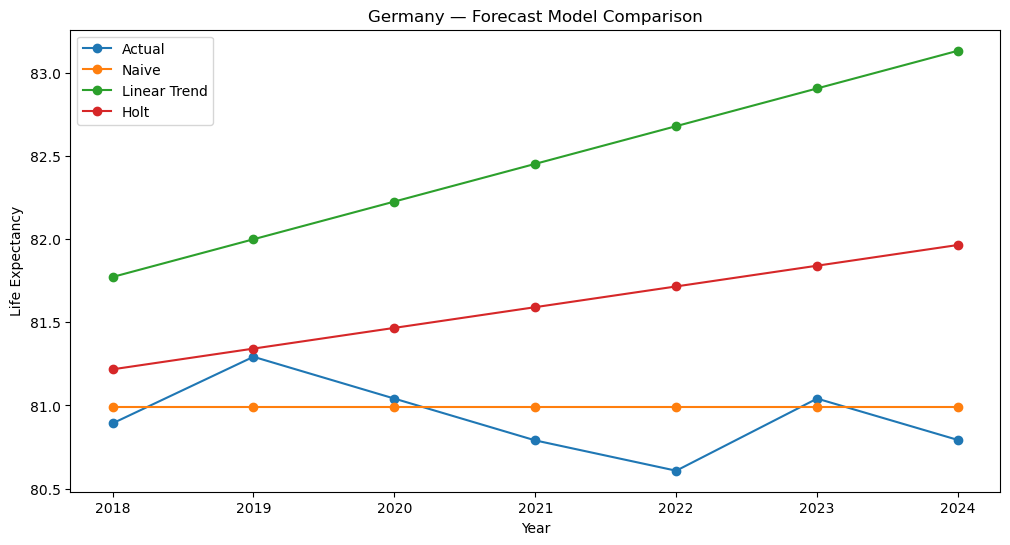

In [473]:
plt.figure(figsize=(12, 6))

plt.plot(
    germany_test["Year"],
    germany_test["Life_Expectancy"],
    marker="o",
    label="Actual"
)

plt.plot(
    germany_test["Year"],
    germany_test["Naive_Forecast"],
    marker="o",
    label="Naive"
)

plt.plot(
    germany_test["Year"],
    germany_trend_pred,
    marker="o",
    label="Linear Trend"
)

plt.plot(
    germany_test["Year"],
    germany_holt_pred,
    marker="o",
    label="Holt"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.title("Germany — Forecast Model Comparison")
plt.legend()

plt.show()

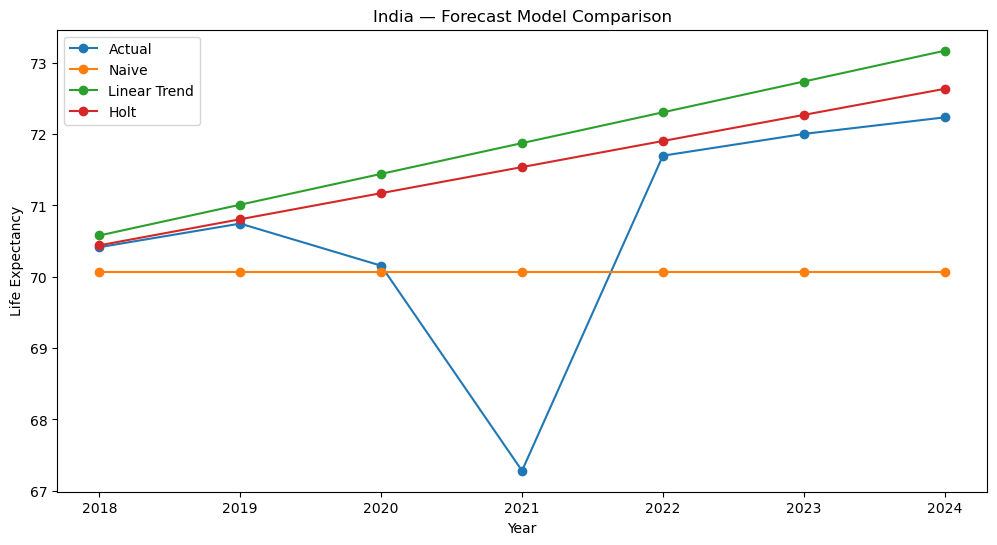

In [475]:
plt.figure(figsize=(12, 6))

plt.plot(
    india_test["Year"],
    india_test["Life_Expectancy"],
    marker="o",
    label="Actual"
)

plt.plot(
    india_test["Year"],
    india_test["Naive_Forecast"],
    marker="o",
    label="Naive"
)

plt.plot(
    india_test["Year"],
    india_trend_pred,
    marker="o",
    label="Linear Trend"
)

plt.plot(
    india_test["Year"],
    india_holt_pred,
    marker="o",
    label="Holt"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.title("India — Forecast Model Comparison")
plt.legend()

plt.show()

In [477]:
germany_forecast_comparison = pd.DataFrame({
    "Year": germany_test["Year"].values,
    "Actual": germany_test["Life_Expectancy"].values,
    "Naive": germany_test["Naive_Forecast"].values,
    "Linear_Trend": germany_trend_pred,
    "Holt": germany_holt_pred
})

germany_forecast_comparison

,Year,Actual,Naive,Linear_Trend,Holt
28,2018,80.892683,80.992683,81.772242,81.217304
29,2019,81.292683,80.992683,81.998844,81.341851
30,2020,81.041463,80.992683,82.225446,81.466398
31,2021,80.790244,80.992683,82.452049,81.590945
32,2022,80.608049,80.992683,82.678651,81.715492
33,2023,81.041463,80.992683,82.905253,81.840039
34,2024,80.792683,80.992683,83.131856,81.964586


In [479]:
india_forecast_comparison = pd.DataFrame({
    "Year": india_test["Year"].values,
    "Actual": india_test["Life_Expectancy"].values,
    "Naive": india_test["Naive_Forecast"].values,
    "Linear_Trend": india_trend_pred,
    "Holt": india_holt_pred
})

india_forecast_comparison

,Year,Actual,Naive,Linear_Trend,Holt
28,2018,70.415,70.068,70.579254,70.441215
29,2019,70.746,70.068,71.010902,70.806887
30,2020,70.156,70.068,71.442550,71.172559
31,2021,67.282,70.068,71.874198,71.538231
32,2022,71.698,70.068,72.305846,71.903903
33,2023,72.003,70.068,72.737494,72.269575
34,2024,72.235,70.068,73.169142,72.635247


## Model 3 — ARIMA Forecast

An ARIMA model is evaluated as an additional time-series forecasting approach. 
The model is trained on the same historical training period used for the Naive, 
Linear Trend, and Holt models and evaluated on the same unseen test period.

ARIMA is tested to determine whether explicitly modelling temporal dependence 
and differenced trends improves out-of-sample forecasting performance.

In [482]:
from statsmodels.tsa.arima.model import ARIMA

In [484]:
arima_germany = ARIMA(
    germany_train["Life_Expectancy"],
    order=(1, 1, 0)
)

arima_germany_fit = arima_germany.fit()

In [486]:
germany_arima_pred = arima_germany_fit.forecast(
    steps=len(germany_test)
)

In [488]:
germany_arima_mae = mean_absolute_error(
    germany_test["Life_Expectancy"],
    germany_arima_pred
)

germany_arima_rmse = mean_squared_error(
    germany_test["Life_Expectancy"],
    germany_arima_pred
) ** 0.5

germany_arima_r2 = r2_score(
    germany_test["Life_Expectancy"],
    germany_arima_pred
)

print("Germany ARIMA(1,1,0)")
print("-------------------")
print("MAE:", round(germany_arima_mae, 4))
print("RMSE:", round(germany_arima_rmse, 4))
print("R²:", round(germany_arima_r2, 4))

Germany ARIMA(1,1,0)
-------------------
MAE: 0.1836
RMSE: 0.2186
R²: -0.1175


In [490]:
arima_india = ARIMA(
    india_train["Life_Expectancy"],
    order=(1, 1, 0)
)

arima_india_fit = arima_india.fit()

In [492]:
india_arima_pred = arima_india_fit.forecast(
    steps=len(india_test)
)

In [494]:
india_arima_mae = mean_absolute_error(
    india_test["Life_Expectancy"],
    india_arima_pred
)

india_arima_rmse = mean_squared_error(
    india_test["Life_Expectancy"],
    india_arima_pred
) ** 0.5

india_arima_r2 = r2_score(
    india_test["Life_Expectancy"],
    india_arima_pred
)

print("India ARIMA(1,1,0)")
print("-----------------")
print("MAE:", round(india_arima_mae, 4))
print("RMSE:", round(india_arima_rmse, 4))
print("R²:", round(india_arima_r2, 4))

India ARIMA(1,1,0)
-----------------
MAE: 0.8253
RMSE: 1.6334
R²: -0.0926


In [496]:
forecast_results = pd.DataFrame({
    "Model": [
        "Naive",
        "Linear Trend",
        "Holt",
        "ARIMA(1,1,0)"
    ],
    "Germany_MAE": [
        germany_naive_mae,
        germany_trend_mae,
        germany_holt_mae,
        germany_arima_mae
    ],
    "Germany_RMSE": [
        germany_naive_rmse,
        germany_trend_rmse,
        germany_holt_rmse,
        germany_arima_rmse
    ],
    "India_MAE": [
        india_naive_mae,
        india_trend_mae,
        india_holt_mae,
        india_arima_mae
    ],
    "India_RMSE": [
        india_naive_rmse,
        india_trend_rmse,
        india_holt_rmse,
        india_arima_rmse
    ]
})

forecast_results

,Model,Germany_MAE,Germany_RMSE,India_MAE,India_RMSE
0,Naive,0.183519,0.218333,1.375857,1.666761
1,Linear Trend,1.529296,1.633075,1.226341,1.875490
2,Holt,0.668192,0.771547,0.890374,1.665916
3,"ARIMA(1,1,0)",0.183632,0.218642,0.825283,1.633368


In [498]:
arima_germany_011 = ARIMA(
    germany_train["Life_Expectancy"],
    order=(0, 1, 1)
).fit()

germany_arima_011_pred = arima_germany_011.forecast(
    steps=len(germany_test)
)

print(
    "Germany ARIMA(0,1,1) MAE:",
    mean_absolute_error(
        germany_test["Life_Expectancy"],
        germany_arima_011_pred
    )
)

print(
    "Germany ARIMA(0,1,1) RMSE:",
    mean_squared_error(
        germany_test["Life_Expectancy"],
        germany_arima_011_pred
    ) ** 0.5
)

Germany ARIMA(0,1,1) MAE: 0.18213487452150495
Germany ARIMA(0,1,1) RMSE: 0.215424687228584


In [499]:
arima_india_011 = ARIMA(
    india_train["Life_Expectancy"],
    order=(0, 1, 1)
).fit()

india_arima_011_pred = arima_india_011.forecast(
    steps=len(india_test)
)

print(
    "India ARIMA(0,1,1) MAE:",
    mean_absolute_error(
        india_test["Life_Expectancy"],
        india_arima_011_pred
    )
)

print(
    "India ARIMA(0,1,1) RMSE:",
    mean_squared_error(
        india_test["Life_Expectancy"],
        india_arima_011_pred
    ) ** 0.5
)

India ARIMA(0,1,1) MAE: 1.29887731384749
India ARIMA(0,1,1) RMSE: 1.628634764159593


In [500]:
arima_germany_111 = ARIMA(
    germany_train["Life_Expectancy"],
    order=(1, 1, 1)
).fit()

germany_arima_111_pred = arima_germany_111.forecast(
    steps=len(germany_test)
)

print(
    "Germany ARIMA(1,1,1) MAE:",
    mean_absolute_error(
        germany_test["Life_Expectancy"],
        germany_arima_111_pred
    )
)

print(
    "Germany ARIMA(1,1,1) RMSE:",
    mean_squared_error(
        germany_test["Life_Expectancy"],
        germany_arima_111_pred
    ) ** 0.5
)

C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Germany ARIMA(1,1,1) MAE: 0.8120163719969042
Germany ARIMA(1,1,1) RMSE: 0.9509236853766193


In [501]:
arima_india_111 = ARIMA(
    india_train["Life_Expectancy"],
    order=(1, 1, 1)
).fit()

india_arima_111_pred = arima_india_111.forecast(
    steps=len(india_test)
)

print(
    "India ARIMA(1,1,1) MAE:",
    mean_absolute_error(
        india_test["Life_Expectancy"],
        india_arima_111_pred
    )
)

print(
    "India ARIMA(1,1,1) RMSE:",
    mean_squared_error(
        india_test["Life_Expectancy"],
        india_arima_111_pred
    ) ** 0.5
)

India ARIMA(1,1,1) MAE: 0.9377845850639639
India ARIMA(1,1,1) RMSE: 1.692810764918293


In [508]:
# ============================================
# ARIMA MODEL COMPARISON
# Germany + India
# ============================================

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd


# --------------------------------------------
# Function to fit ARIMA and calculate metrics
# --------------------------------------------

def evaluate_arima(train, test, order):
    
    model = ARIMA(
        train["Life_Expectancy"],
        order=order
    )
    
    fitted_model = model.fit()
    
    predictions = fitted_model.forecast(
        steps=len(test)
    )
    
    mae = mean_absolute_error(
        test["Life_Expectancy"],
        predictions
    )
    
    rmse = mean_squared_error(
        test["Life_Expectancy"],
        predictions
    ) ** 0.5
    
    return mae, rmse


# --------------------------------------------
# ARIMA models we want to compare
# --------------------------------------------

arima_orders = [
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1)
]


# --------------------------------------------
# Evaluate Germany
# --------------------------------------------

germany_results = []

for order in arima_orders:
    
    mae, rmse = evaluate_arima(
        germany_train,
        germany_test,
        order
    )
    
    germany_results.append({
        "Country": "Germany",
        "ARIMA": f"ARIMA{order}",
        "MAE": mae,
        "RMSE": rmse
    })


# --------------------------------------------
# Evaluate India
# --------------------------------------------

india_results = []

for order in arima_orders:
    
    mae, rmse = evaluate_arima(
        india_train,
        india_test,
        order
    )
    
    india_results.append({
        "Country": "India",
        "ARIMA": f"ARIMA{order}",
        "MAE": mae,
        "RMSE": rmse
    })


# --------------------------------------------
# Combine results
# --------------------------------------------

arima_comparison = pd.DataFrame(
    germany_results + india_results
)


# Round results
arima_comparison["MAE"] = arima_comparison["MAE"].round(4)
arima_comparison["RMSE"] = arima_comparison["RMSE"].round(4)


# Display table
arima_comparison

C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Admin\Documents\anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,Country,ARIMA,MAE,RMSE
0,Germany,"ARIMA(1, 1, 0)",0.1836,0.2186
1,Germany,"ARIMA(0, 1, 1)",0.1821,0.2154
2,Germany,"ARIMA(1, 1, 1)",0.8120,0.9509
3,India,"ARIMA(1, 1, 0)",0.8253,1.6334
4,India,"ARIMA(0, 1, 1)",1.2989,1.6286
5,India,"ARIMA(1, 1, 1)",0.9378,1.6928


In [510]:
# Find the best ARIMA model for each country based on MAE

best_arima_models = (
    arima_comparison
    .loc[
        arima_comparison.groupby("Country")["MAE"].idxmin()
    ]
    .reset_index(drop=True)
)

print("Best ARIMA model for each country:")
best_arima_models

Best ARIMA model for each country:


,Country,ARIMA,MAE,RMSE
0,Germany,"ARIMA(0, 1, 1)",0.1821,0.2154
1,India,"ARIMA(1, 1, 0)",0.8253,1.6334
